# Allen brain observatory data exploration

Based on the youtube video: https://www.youtube.com/watch?v=dO99XLlHA90

Start by defining the path to the manifest.

In [1]:
PATH_TO_MANIFEST = "brain_observatory/manifest.json"

Then we import the necessary libraries.

In [20]:
import os
import pandas as pd
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

We set up the BrainObservatoryCache.

In [5]:
boc = BrainObservatoryCache(os.path.join(os.curdir, PATH_TO_MANIFEST))

Next we explore the data with several `.get_{something}` methods

In [6]:
boc.get_all_targeted_structures()

['VISal', 'VISam', 'VISl', 'VISp', 'VISpm', 'VISrl']

In [7]:
boc.get_all_imaging_depths()

[175,
 185,
 195,
 200,
 205,
 225,
 250,
 265,
 275,
 276,
 285,
 300,
 320,
 325,
 335,
 350,
 365,
 375,
 390,
 400,
 550,
 570,
 625]

In [9]:
boc.get_all_cre_lines()

['Cux2-CreERT2',
 'Emx1-IRES-Cre',
 'Fezf2-CreER',
 'Nr5a1-Cre',
 'Ntsr1-Cre_GN220',
 'Pvalb-IRES-Cre',
 'Rbp4-Cre_KL100',
 'Rorb-IRES2-Cre',
 'Scnn1a-Tg3-Cre',
 'Slc17a7-IRES2-Cre',
 'Sst-IRES-Cre',
 'Tlx3-Cre_PL56',
 'Vip-IRES-Cre']

In [10]:
boc.get_all_reporter_lines()

['Ai148(TIT2L-GC6f-ICL-tTA2)',
 'Ai162(TIT2L-GC6s-ICL-tTA2)',
 'Ai93(TITL-GCaMP6f)',
 'Ai93(TITL-GCaMP6f)-hyg',
 'Ai94(TITL-GCaMP6s)']

In [11]:
boc.get_all_stimuli()

['drifting_gratings',
 'locally_sparse_noise',
 'locally_sparse_noise_4deg',
 'locally_sparse_noise_8deg',
 'natural_movie_one',
 'natural_movie_three',
 'natural_movie_two',
 'natural_scenes',
 'spontaneous',
 'static_gratings']

In [12]:
boc.get_all_session_types()

['OPHYS_1_images_A',
 'OPHYS_1_images_B',
 'OPHYS_2_images_A_passive',
 'OPHYS_2_images_B_passive',
 'OPHYS_3_images_A',
 'OPHYS_3_images_B',
 'OPHYS_4_images_A',
 'OPHYS_4_images_B',
 'OPHYS_5_images_A_passive',
 'OPHYS_5_images_B_passive',
 'OPHYS_6_images_A',
 'OPHYS_6_images_B',
 'OPHYS_7_receptive_field_mapping',
 'three_session_A',
 'three_session_B',
 'three_session_C',
 'three_session_C2']

## Experiment containers & sessions

In [13]:
visual_area = "VISp"
cre_line = "Cux2-CreERT2"

In [16]:
exps = boc.get_experiment_containers(targeted_structures=[visual_area], cre_lines=[cre_line])

In [18]:
len(exps)

16

In [21]:
pd.DataFrame(exps)

,id,imaging_depth,targeted_structure,cre_line,reporter_line,donor_name,specimen_name,tags,failed
0,511510736,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),222426,Cux2-CreERT2;Camk2a-tTA;Ai93-222426,[],False
1,511510855,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),229106,Cux2-CreERT2;Camk2a-tTA;Ai93-229106,[],False
2,511509529,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),222420,Cux2-CreERT2;Camk2a-tTA;Ai93-222420,[],False
3,511507650,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),222424,Cux2-CreERT2;Camk2a-tTA;Ai93-222424,[],False
4,702934962,275,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),382421,Cux2-CreERT2;Camk2a-tTA;Ai93-382421,[],False
5,645413757,275,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),348262,Cux2-CreERT2;Camk2a-tTA;Ai93-348262,[],False
6,659767480,275,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),360565,Cux2-CreERT2;Camk2a-tTA;Ai93-360565,[],False
7,511510650,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),222425,Cux2-CreERT2;Camk2a-tTA;Ai93-222425,[],False
8,712178509,275,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),390323,Cux2-CreERT2;Camk2a-tTA;Ai93-390323,[],False
9,511510667,275,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),222420,Cux2-CreERT2;Camk2a-tTA;Ai93-222420,[],False


In [22]:
experiment_container_id = 511510736

In [23]:
sessions = boc.get_ophys_experiments(experiment_container_ids=[experiment_container_id])

In [24]:
pd.DataFrame(sessions)

,id,imaging_depth,targeted_structure,cre_line,reporter_line,acquisition_age_days,experiment_container_id,session_type,donor_name,specimen_name,fail_eye_tracking
0,501559087,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),103,511510736,three_session_B,222426,Cux2-CreERT2;Camk2a-tTA;Ai93-222426,True
1,501704220,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),104,511510736,three_session_A,222426,Cux2-CreERT2;Camk2a-tTA;Ai93-222426,True
2,501474098,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),102,511510736,three_session_C,222426,Cux2-CreERT2;Camk2a-tTA;Ai93-222426,True


Let's get the id for the imaging session for this container natural scenes.

In [25]:
session_id = boc.get_ophys_experiments(experiment_container_ids=[experiment_container_id], stimuli=["natural_scenes"])[0]["id"]

In [26]:
session_id

501559087

## Getting data for an experiment

In [27]:
data_set = boc.get_ophys_experiment_data(session_id)

2026-04-06 23:15:36,903 allensdk.api.api.retrieve_file_over_http INFO     Downloading URL: http://api.brain-map.org/api/v2/well_known_file_download/514429113


In [28]:
max_projection = data_set.get_max_projection()

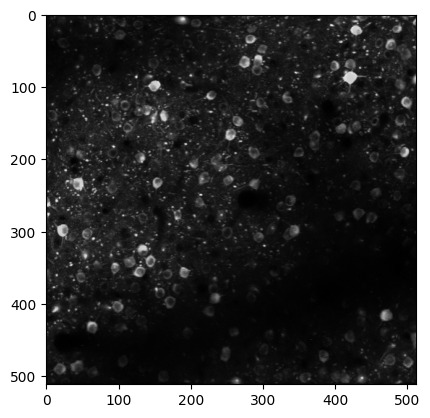

In [29]:
import matplotlib.pyplot as plt
plt.imshow(max_projection, cmap="gray")

In [30]:
rois = data_set.get_roi_mask_array()

In [31]:
rois.shape

(174, 512, 512)

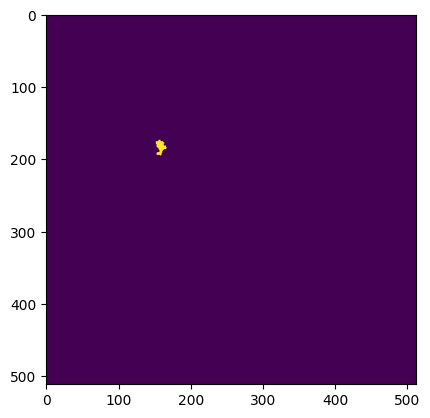

In [32]:
plt.imshow(rois[23,:,:])

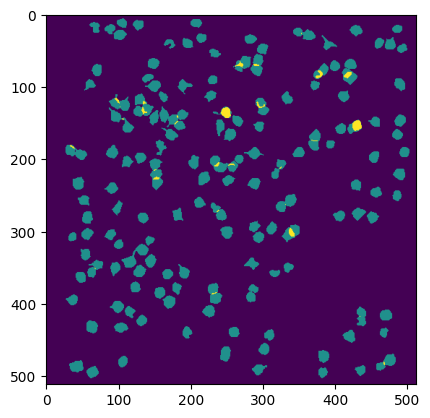

In [34]:
plt.imshow(rois.sum(axis=0))

In [35]:
ts, dff = data_set.get_dff_traces()

In [36]:
dff.shape

(174, 113888)

Text(0, 0.5, 'DFF (%)')

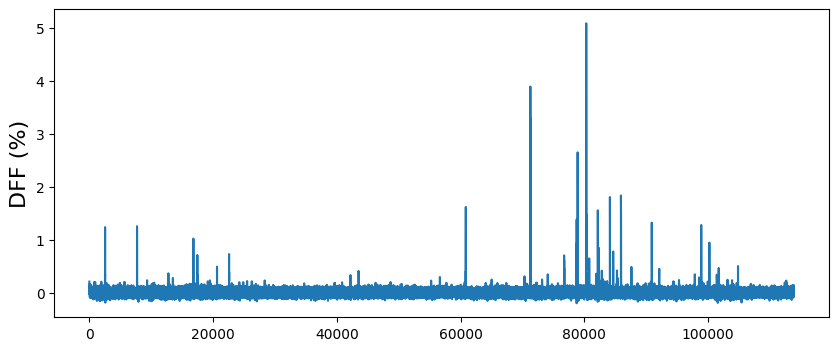

In [37]:
plt.figure(figsize=(10,4))
plt.plot(dff[0,:])
plt.ylabel("DFF (%)", fontsize=16)

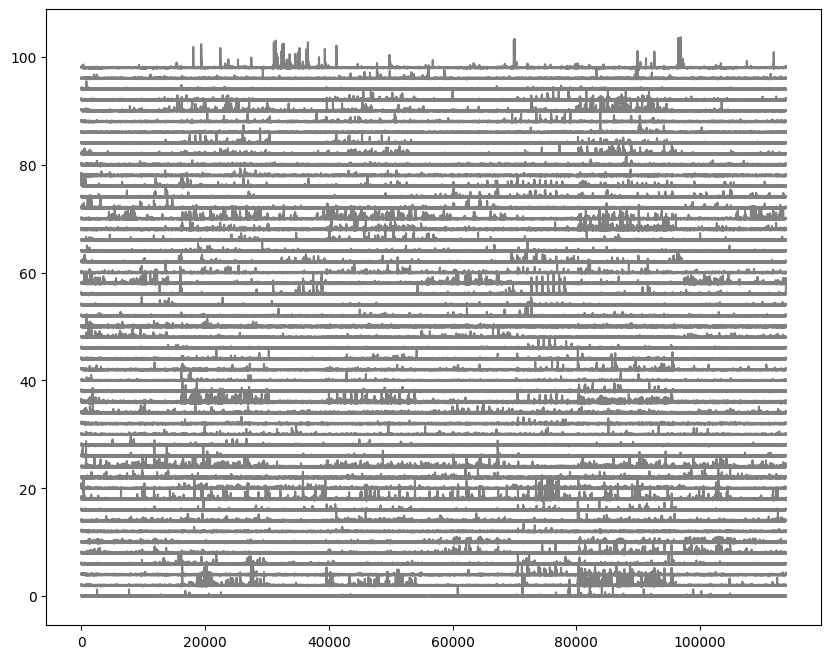

In [38]:
fig = plt.figure(figsize=(10,8))
for i in range(50):
    plt.plot(dff[i,:]+(i*2), color="gray")

Stimulus epochs:

In [39]:
stim_epoch = data_set.get_stimulus_epoch_table()

In [40]:
stim_epoch

,stimulus,start,end
0,static_gratings,747,15196
1,natural_scenes,16100,30551
2,spontaneous,30701,39581
3,natural_scenes,39582,54050
4,static_gratings,54953,69403
5,natural_movie_one,70307,79338
6,natural_scenes,80241,96126
7,static_gratings,97406,113662


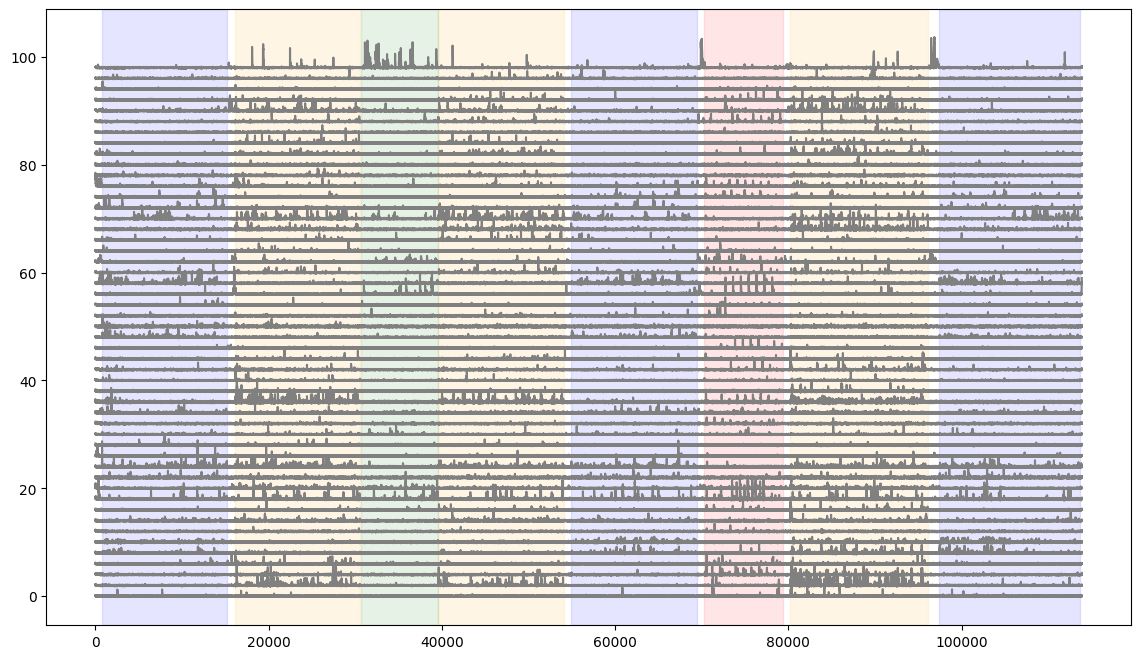

In [43]:
fig = plt.figure(figsize=(14, 8))
for i in range(50):
    plt.plot(dff[i,:]+(i*2), color="gray")

# For each stimulus, shade the plot a different color
colors = ["blue", "orange", "green", "red"]
for c, stim_name in enumerate(stim_epoch.stimulus.unique()):
    stim = stim_epoch[stim_epoch.stimulus==stim_name]
    for j in range(len(stim)):
        plt.axvspan(xmin=stim.start.iloc[j], xmax=stim.end.iloc[j], color=colors[c], alpha=0.1)

In [44]:
dxcm, tsd = data_set.get_running_speed()

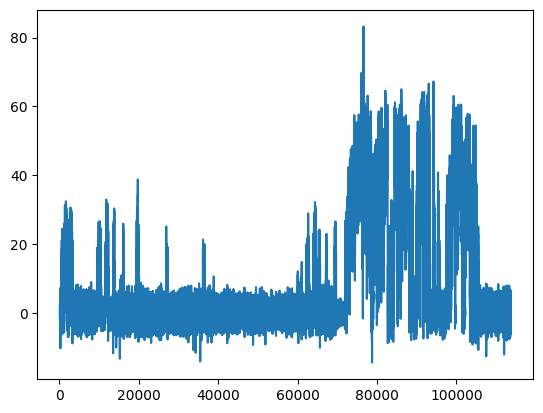

In [45]:
plt.plot(dxcm)

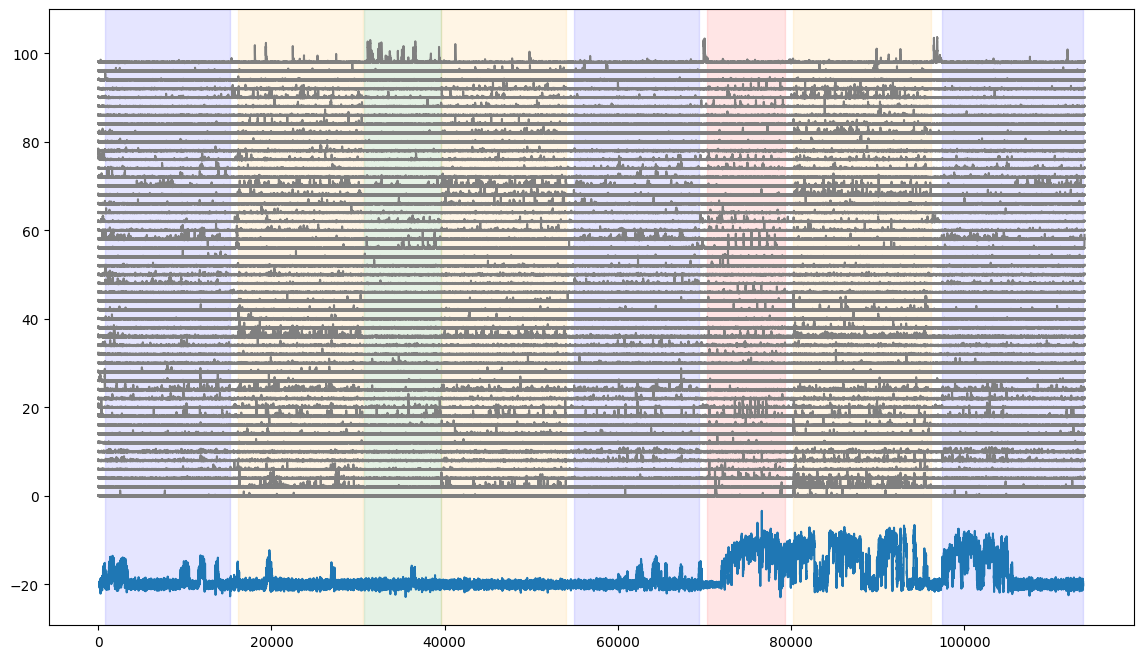

In [47]:
fig = plt.figure(figsize=(14, 8))
for i in range(50):
    plt.plot(dff[i,:]+(i*2), color="gray")

# Add running speed to figure above
plt.plot((0.2 * dxcm)-20)

# For each stimulus, shade the plot a different color
colors = ["blue", "orange", "green", "red"]
for c, stim_name in enumerate(stim_epoch.stimulus.unique()):
    stim = stim_epoch[stim_epoch.stimulus==stim_name]
    for j in range(len(stim)):
        plt.axvspan(xmin=stim.start.iloc[j], xmax=stim.end.iloc[j], color=colors[c], alpha=0.1)

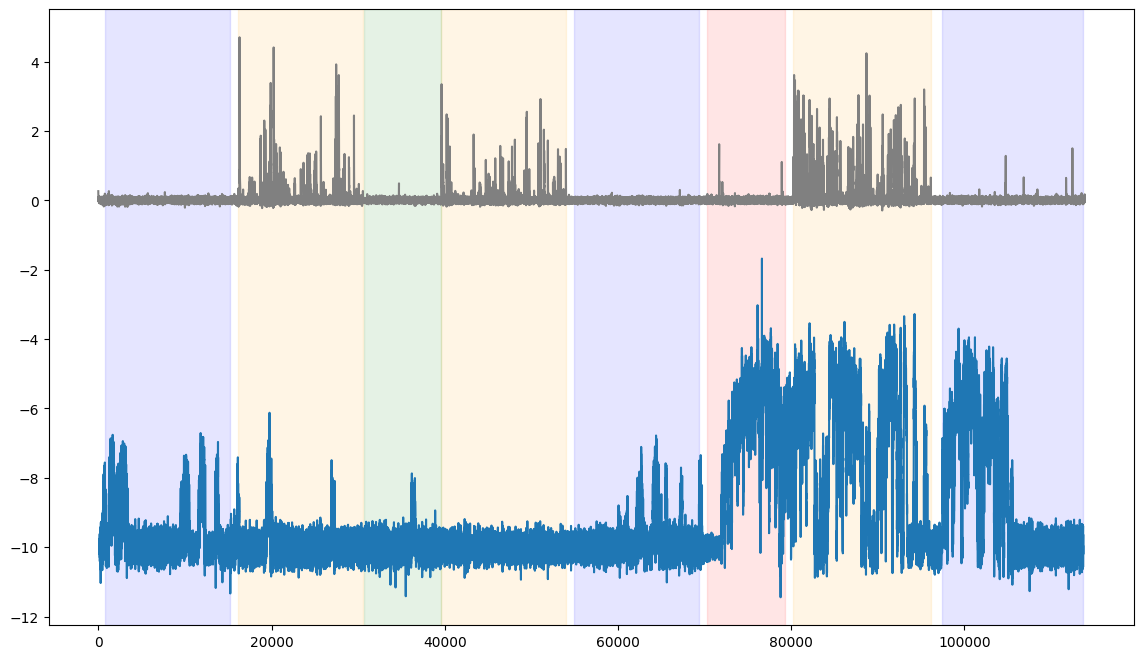

In [50]:
fig = plt.figure(figsize=(14, 8))
plt.plot(dff[1,:], color="gray")

# Add running speed to figure above
plt.plot((0.1 * dxcm)-10)

# For each stimulus, shade the plot a different color
colors = ["blue", "orange", "green", "red"]
for c, stim_name in enumerate(stim_epoch.stimulus.unique()):
    stim = stim_epoch[stim_epoch.stimulus==stim_name]
    for j in range(len(stim)):
        plt.axvspan(xmin=stim.start.iloc[j], xmax=stim.end.iloc[j], color=colors[c], alpha=0.1)

### Extracted events

In [51]:
events = boc.get_ophys_experiment_events(session_id)

2026-04-06 23:35:10,951 allensdk.api.api.retrieve_file_over_http INFO     Downloading URL: http://api.brain-map.org/api/v2/well_known_file_download/739721211


In [53]:
events.shape

(174, 113888)

(20000.0, 21000.0)

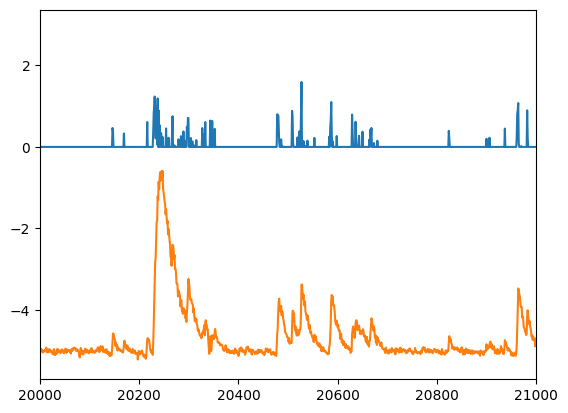

In [54]:
plt.plot(2*events[1,:])
plt.plot(dff[1,:]-5)
plt.xlim(20000, 21000)

We can also make the same type of figure we have made before.

### Stimulus table

In [58]:
natural_scene_table = data_set.get_stimulus_table("natural_scenes")

In [59]:
natural_scene_table.head()

,frame,start,end
0,81,16100,16107
1,33,16108,16115
2,76,16115,16122
3,13,16123,16130
4,56,16130,16137


In [60]:
static_gratings_table = data_set.get_stimulus_table("static_gratings")

In [61]:
static_gratings_table.head()

,orientation,spatial_frequency,phase,start,end
0,90.0,0.04,0.50,747,754
1,150.0,0.04,0.50,754,761
2,30.0,0.02,0.00,762,769
3,0.0,0.32,0.50,769,776
4,150.0,0.16,0.75,777,784


In [62]:
natural_scene_template = data_set.get_stimulus_template("natural_scenes")

In [63]:
natural_scene_template.shape

(118, 918, 1174)

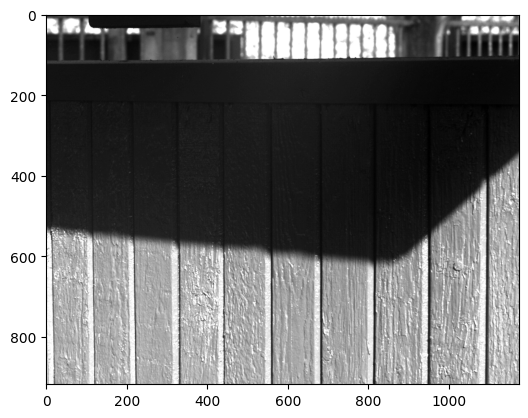

In [64]:
plt.imshow(natural_scene_template[81,:,:], cmap="gray")

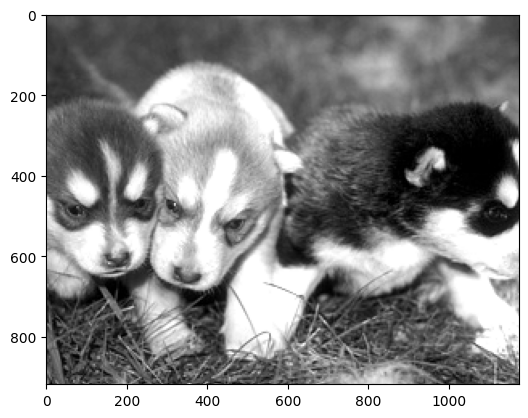

In [65]:
plt.imshow(natural_scene_template[33,:,:], cmap="gray")

## Metadata

In [66]:
data_set.get_metadata()

{'sex': 'male',
 'targeted_structure': 'VISp',
 'ophys_experiment_id': 501559087,
 'experiment_container_id': 511510736,
 'excitation_lambda': '910 nanometers',
 'indicator': 'GCaMP6f',
 'fov': '400x400 microns (512 x 512 pixels)',
 'genotype': 'Cux2-CreERT2/wt;Camk2a-tTA/wt;Ai93(TITL-GCaMP6f)/Ai93(TITL-GCaMP6f)',
 'session_start_time': datetime.datetime(2016, 2, 4, 10, 25, 24),
 'session_type': 'three_session_B',
 'specimen_name': 'Cux2-CreERT2;Camk2a-tTA;Ai93-222426',
 'cre_line': 'Cux2-CreERT2/wt',
 'imaging_depth_um': 175,
 'age_days': 104,
 'device': 'Nikon A1R-MP multiphoton microscope',
 'device_name': 'CAM2P.2',
 'pipeline_version': '3.0'}